 ## Una tienda internacional desea iniciar una granja de sandias en Brasil y se comenzó una prueba A/B la cual no fue finalizada, pero dejaron algunas especificaciones técnicas: 
•	 Nombre de la prueba: recommender_system_test  
•	Grupos: А (control), B (nuevo embudo de pago)  
•	Launch date: 2020-12-07  
•	Fecha en la que dejaron de aceptar nuevos usuarios: 2020-12-21  
•	Fecha de finalización: 2021-01-01  
•	Audiencia: 15% de los nuevos usuarios de la región de la UE  
•	Propósito de la prueba: probar cambios relacionados con la introducción de un sistema de recomendaciones mejorado  
•	Resultado esperado: dentro de los 14 días posteriores a la inscripción, los usuarios mostrarán una mejor conversión en vistas de la página del producto (el evento product_page), instancias de agregar artículos al carrito de compras (product_card) y compras (purchase). En cada etapa del embudo product_page → product_card → purchase, habrá al menos un 10% de aumento.  
•	Número previsto de participantes de la prueba: 6 000  

Junto con 4 data sets que recopilan información


# PROYECTO TEST A/B (Nombre de la prueba: recommender_system_test)

In [1]:
%pip install matplotlib 
%pip install seaborn
%pip install plotly.express

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# 1.Importar Librerias

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import math as mt
from matplotlib import pyplot as plt
from scipy import stats as st
import datetime
from statsmodels.stats.proportion import proportions_ztest
import plotly.express as px

Como primer paso antes de realizar cualquier análisis o dar comienzo con el es necesario empezar importando aquellas librerías a utilizar o que podrían servirnos.  
    Ya que el análisis consiste en una prueba A/B librerias como seaborn, matplotlib, datetime y scipy además de pandas y numpy podrían ser las adecuadas.

# 2.Importar Datasets

In [3]:
df_marketing = pd.read_csv('c:/Users/PC/Proyecto_15_Revisión_Prueba_AB/ab_project_marketing_events_us.csv')
df_new_users = pd.read_csv('c:/Users/PC/Proyecto_15_Revisión_Prueba_AB/final_ab_new_users_upd_us.csv')
df_events =  pd.read_csv('c:/Users/PC/Proyecto_15_Revisión_Prueba_AB/final_ab_events_upd_us.csv')
df_participants = pd.read_csv('c:/Users/PC/Proyecto_15_Revisión_Prueba_AB/final_ab_participants_upd_us.csv')

# 3.Procesar Datos 

# Dataset Marketing

In [4]:
df_marketing.info(show_counts=True)
print()
print('Estos son los nombres de las columnas:\n', df_marketing.columns)
print()
print('Hay tantasfilas y columnas=', df_marketing.shape)
print()
df_marketing

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 580.0+ bytes

Estos son los nombres de las columnas:
 Index(['name', 'regions', 'start_dt', 'finish_dt'], dtype='object')

Hay tantasfilas y columnas= (14, 4)



,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11
5,Black Friday Ads Campaign,"EU, CIS, APAC, N.America",2020-11-26,2020-12-01
6,Chinese New Year Promo,APAC,2020-01-25,2020-02-07
7,Labor day (May 1st) Ads Campaign,"EU, CIS, APAC",2020-05-01,2020-05-03
8,International Women's Day Promo,"EU, CIS, APAC",2020-03-08,2020-03-10
9,Victory Day CIS (May 9th) Event,CIS,2020-05-09,2020-05-11


## Dataset new_users

In [5]:
df_new_users.info(show_counts=True)
print()
print('Estos son los nombres de las columnas:\n', df_new_users.columns)
print()
print('Hay tantasfilas y columnas=', df_new_users.shape)
print()
df_new_users

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-null  object
 1   first_date  58703 non-null  object
 2   region      58703 non-null  object
 3   device      58703 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB

Estos son los nombres de las columnas:
 Index(['user_id', 'first_date', 'region', 'device'], dtype='object')

Hay tantasfilas y columnas= (58703, 4)



,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone
...,...,...,...,...
58698,1DB53B933257165D,2020-12-20,EU,Android
58699,538643EB4527ED03,2020-12-20,EU,Mac
58700,7ADEE837D5D8CBBD,2020-12-20,EU,PC
58701,1C7D23927835213F,2020-12-20,EU,iPhone


In [6]:
df_new_users['first_date'] = pd.to_datetime(df_new_users['first_date'], errors='coerce')
df_new_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     58703 non-null  object        
 1   first_date  58703 non-null  datetime64[ns]
 2   region      58703 non-null  object        
 3   device      58703 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 1.8+ MB


Para este segundo data set también con está rápida revisión se define como un dataset tambíen lipmio y con los valores adecuados solo cambiamos los tipo object de la columna first_date a datetime

In [7]:
print('Hay ', df_new_users.duplicated().sum(), 'filas completas duplicadas' )
print()
print('Hay', df_new_users['user_id'].duplicated().sum(), 'usuarios duplicados')
print()
df_new_users.info()
print()
df_new_users.head()

Hay  0 filas completas duplicadas

Hay 0 usuarios duplicados

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     58703 non-null  object        
 1   first_date  58703 non-null  datetime64[ns]
 2   region      58703 non-null  object        
 3   device      58703 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 1.8+ MB



,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


In [8]:
print('Hay tantas regiones en este dataset:\n', df_new_users['region'].unique())
print()
print('Hay tantos dispositivos únicos:\n', df_new_users['device'].unique())

Hay tantas regiones en este dataset:
 ['EU' 'N.America' 'APAC' 'CIS']

Hay tantos dispositivos únicos:
 ['PC' 'Android' 'iPhone' 'Mac']


## Dataset events

In [9]:
df_events.info(show_counts=True)
print()
print('Estos son los nombres de las columnas:\n', df_events.columns)
print()
print('Hay tantasfilas y columnas=', df_events.shape)
print()
df_events

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  object 
 1   event_dt    423761 non-null  object 
 2   event_name  423761 non-null  object 
 3   details     60314 non-null   float64
dtypes: float64(1), object(3)
memory usage: 12.9+ MB

Estos son los nombres de las columnas:
 Index(['user_id', 'event_dt', 'event_name', 'details'], dtype='object')

Hay tantasfilas y columnas= (423761, 4)



,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99
...,...,...,...,...
423756,245E85F65C358E08,2020-12-30 19:35:55,login,NaN
423757,9385A108F5A0A7A7,2020-12-30 10:54:15,login,NaN
423758,DB650B7559AC6EAC,2020-12-30 10:59:09,login,NaN
423759,F80C9BDDEA02E53C,2020-12-30 09:53:39,login,NaN


In [10]:
print('Hay ', df_events.duplicated().sum(), 'filas completas duplicadas' )
print()
print('Hay', df_events['user_id'].duplicated().sum(), 'usuarios duplicados')
print()
print('Hay', df_events.duplicated(subset=['user_id', 'event_dt']).sum(), 'usuarios y fechas duplicados')
print()
df_events.info()
print()
duplicados = df_events[df_events.duplicated(subset=['user_id', 'event_dt'], keep=False)] #el dataset duplicados es para verificación
print(duplicados.sort_values(by=['user_id', 'event_dt']))

Hay  0 filas completas duplicadas

Hay 365058 usuarios duplicados

Hay 145414 usuarios y fechas duplicados

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  object 
 1   event_dt    423761 non-null  object 
 2   event_name  423761 non-null  object 
 3   details     60314 non-null   float64
dtypes: float64(1), object(3)
memory usage: 12.9+ MB

                 user_id             event_dt    event_name  details
15989   000199F1887AE5E6  2020-12-14 09:56:09      purchase     4.99
152556  000199F1887AE5E6  2020-12-14 09:56:09  product_page      NaN
289743  000199F1887AE5E6  2020-12-14 09:56:09         login      NaN
19145   000199F1887AE5E6  2020-12-15 07:22:56      purchase     4.99
79325   000199F1887AE5E6  2020-12-15 07:22:56  product_cart      NaN
...                  ...                  ...           ...   

In [11]:
print('Estos son los eventos únicos:\n', df_events['event_name'].unique())

Estos son los eventos únicos:
 ['purchase' 'product_cart' 'product_page' 'login']


Para el dataset events observamos que hay valores nulos algo que en los datasets anteriores no ocurrió, pero esos valores nulos parecen ser para todos los valores que están antes de que los usuarios hagan compras ya que la columna details se refiere al total de USD de purchase(compras).  
También cambiamos la columna evento_dt a datetime y como último paso al revisar los cuplicados encontramos que tanto usuarios como eventos hay valores duplicaso pero si se hace la busqeuda incluyendo la columna evento entonces hay cero, ¿Por qué aparecen estos valores duplicados puede haber varias razones:  
    
•	Eventos simultáneos: El sistema registró dos eventos distintos (ej. "clic" y "compra") al mismo tiempo para el mismo usuario.  

•	Falta de precisión en el tiempo: Si el event_dt solo llega hasta segundos, pero los eventos ocurrieron con milisegundos de diferencia, colisionarán como si fueran al mismo tiempo.    

•	Error de ingesta: Los datos se cargaron dos veces, pero alguna columna (como details) tiene una ligera variación (como un ID de sesión o un espacio en blanco) que evita que sea un duplicado "total". 

Pero los eventos parecen ser validos por lo que no parece buena idea eliminarlos y mas cuando al incluir la columna evento entonces desaparecen por completos los duplicados


In [12]:
print('Hay', df_events.duplicated(subset=['user_id', 'event_dt', 'event_name']).sum(), 'usuariosy fechas duplicados')

Hay 0 usuariosy fechas duplicados


In [13]:
nulos_details = df_events[df_events['details'].isna()]

comprobacion_NA = (nulos_details['event_name'] != 'purchase').all()

if comprobacion_NA:
    print("Todos los NA en 'details' corresponden a eventos que no son 'purchase'.")
else:
    print("Sí, hay excepciones.")

Todos los NA en 'details' corresponden a eventos que no son 'purchase'.


Con esta función if else comprobamos que todos los valores nulos pertenecen alos eventos que no son purchase

## Dataset Participants

In [14]:
df_participants.info(show_counts=True)
print()
print('Estos son los nombres de las columnas:\n', df_participants.columns)
print()
print('Hay tantasfilas y columnas=', df_participants.shape)
print()
df_participants

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
dtypes: object(3)
memory usage: 340.6+ KB

Estos son los nombres de las columnas:
 Index(['user_id', 'group', 'ab_test'], dtype='object')

Hay tantasfilas y columnas= (14525, 3)



,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test
...,...,...,...
14520,1D302F8688B91781,B,interface_eu_test
14521,3DE51B726983B657,A,interface_eu_test
14522,F501F79D332BE86C,A,interface_eu_test
14523,63FBE257B05F2245,A,interface_eu_test


El último dataset donde se dividen los grupos para las pruebas A/B parece estar correcto tanto en sus columnas y filas y no hay indicios de valores nulos pero hay que revisar aún tanto duplicados como los valore únicos que pertenecen a ciertas columnas como group y ab_test

In [15]:
print('Hay tantos grupos únicos:\n', df_participants['group'].unique())
print()
print('Hay tantos tipos de usuario en ab_test únicos:\n', df_participants['ab_test'].unique())

Hay tantos grupos únicos:
 ['A' 'B']

Hay tantos tipos de usuario en ab_test únicos:
 ['recommender_system_test' 'interface_eu_test']


Ahora ya sabemos que todos los usuarios pertenencena un grupo A ó B y a recommender_system_test ó interface_eu_test

In [16]:
print('Hay ', df_participants.duplicated().sum(), 'filas completas duplicadas')
print()
print('Hay', df_participants.duplicated(subset=['user_id', 'group']).sum(), 'usuarios y grupos duplicados')
print()
print('Hay', df_participants.duplicated(subset=['user_id', 'ab_test']).sum(), 'usuarios y ab_test duplicados')
print()
df_participants.head()

Hay  0 filas completas duplicadas

Hay 446 usuarios y grupos duplicados

Hay 0 usuarios y ab_test duplicados



,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


In [17]:
groups_per_user = df_participants.groupby('user_id')['group'].unique()
print(groups_per_user)
print()
same_ids =groups_per_user[groups_per_user.apply(lambda x: all(item in x for item in ['A', 'B']))]
print(same_ids.index.tolist())
print()
print('Son un total de usuarios pertenencintes a ambos grupos de:\n', len(same_ids))

user_id
0002CE61FF2C4011       [A]
001064FEAAB631A1       [B]
0010A1C096941592       [A]
001E72F50D1C48FA       [B]
002412F1EB3F6E38       [A]
                     ...  
FFE600EEC4BA7685       [A]
FFE7FC140521F5F6       [B]
FFEFC0E55C1CCD4F       [B]
FFF28D02B1EACBE1    [B, A]
FFF58BC33966EB51       [B]
Name: group, Length: 13638, dtype: object

['0082295A41A867B5', '00E68F103C66C1F7', '02313B9E82255F47', '04F2CF340B4F3822', '051D59BC38C3B3AA', '067D05BD30F04F2E', '08589AA89496453B', '0980BF24051C806A', '0A0141A363E2E051', '0ADFFFE9C0D60092', '0B0D84A866817D84', '0BA00E790AA510C1', '0BC7C730D40D19D3', '0C2E77C6A381704A', '0CA93D3A4A1D8389', '0CC466ED84E0756D', '0D77D907C24CDAC1', '0DABE6F3956778ED', '0DB417842D3B79A2', '0EA9AB1C2A159C77', '0EBE4BDE16D19DC0', '0EE3092A08562765', '0FBF679EA1340786', '10779B9305942526', '10F028FB8193F8C1', '115ABCFDBDDB5950', '123C3AC236BE84F0', '124B6B7F19141CCC', '12A77BCF101643B5', '133F64DC5E24F047', '1381632DA8AD52C0', '1382E5D05428EBCD', '13AA9B89A2

In [18]:
contaminated_users = df_participants.groupby('user_id')['group'].nunique()
contaminated_users = contaminated_users[contaminated_users > 1].index

df_participants_clean = df_participants[~df_participants['user_id'].isin(contaminated_users)]

print(f"Usuarios eliminados: {len(contaminated_users)}")
print()
print(f"Registros restantes: {len(df_participants_clean)}")
print()
print('1= comprobación de usuariso eliminados', df_participants_clean.groupby('user_id')['group'].nunique().max())
print()
display(df_participants_clean)

Usuarios eliminados: 441

Registros restantes: 13643

1= comprobación de usuariso eliminados 1



,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test
...,...,...,...
14520,1D302F8688B91781,B,interface_eu_test
14521,3DE51B726983B657,A,interface_eu_test
14522,F501F79D332BE86C,A,interface_eu_test
14523,63FBE257B05F2245,A,interface_eu_test


El dataset participants eoncontramos que hay usuarios que estan dentro del grupo A al mismo tiempo que en el grupo B; son 441 usuarios que estan en ambos grupos lo cual para cada grupo suman 882 usuarios, esto representa un 6% de los valores lo cual pude provocar un sesgo en análisis d ela spruebas A/B asi que los eliminamos dejando ahora más de 13,600 usuarios para lsa pruebas

## 3.1 Continuación procesamiento de datos(revisión de valores en rango)

In [19]:
df_new_users.describe()

,first_date
count,58703
mean,2020-12-15 01:59:36.573599488
min,2020-12-07 00:00:00
25%,2020-12-11 00:00:00
50%,2020-12-15 00:00:00
75%,2020-12-20 00:00:00
max,2020-12-23 00:00:00


Para ir comenzado con el análisis exploratorio de datos lo primero es saber si solo tenemos en el dataset de new-Users registros solo entre el 7 y el 21 de diciembre y encontramo sque si hay registros hasta el 23 de diciembre

In [20]:
users_out_21december = df_new_users[df_new_users['first_date'] > '2020-12-21']
display(users_out_21december) #utilizado para saber cuales usuariso quedan fuerra de la fecha
print()
print('Usuarios depúes del 21 de diciembre:\n', len(users_out_21december))

,user_id,first_date,region,device
22757,5815F7ECE74D949F,2020-12-22,CIS,PC
22758,32EAEA5E903E3BC1,2020-12-22,N.America,Android
22759,9DF7A3C46487EF0B,2020-12-22,EU,Android
22760,ADE98C6440423287,2020-12-22,EU,iPhone
22761,5A5833D3AEA75255,2020-12-22,N.America,PC
...,...,...,...,...
32118,165AFCBF42C043F8,2020-12-23,EU,PC
32119,54E7F36C0E976E24,2020-12-23,EU,Android
32120,7E43EB2E03A33E78,2020-12-23,EU,PC
32121,B8B679DEE9F2CA06,2020-12-23,EU,PC



Usuarios depúes del 21 de diciembre:
 5263


La cantidad de usuarios registrados en el dataset después del 21 de diciembre son mas de 5,200, un 9% del total de los datos no tenemos información suficiente  para saber porque se filtraron esos usuarios como para dejarlos en nuestra prueba.

In [21]:
df_users_in_21d = df_new_users[df_new_users['first_date'] < '2020-12-22']
df_users_in_21d #nuevo dtaset con lso usuariso dentro de la fecha

,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone
...,...,...,...,...
58698,1DB53B933257165D,2020-12-20,EU,Android
58699,538643EB4527ED03,2020-12-20,EU,Mac
58700,7ADEE837D5D8CBBD,2020-12-20,EU,PC
58701,1C7D23927835213F,2020-12-20,EU,iPhone


In [22]:
df_events['event_dt'].describe()

count                  423761
unique                 257138
top       2020-12-14 18:54:55
freq                       10
Name: event_dt, dtype: object

## 4. Análisis explratoriod e datos(EDA)

## 4.1 Conversión en las etapas del embudo

Hemos revisado anteriormente que los datos no tengan valores ausentes ó duplicados que afecten el análisis, así como buscar si hubo usuarios tanto en la muestra A como B, hicimos cambio de tipos de valores de object a datetime, y tambénnos aseguramso que los nuevo usuarios esten en el rango de fechas del 7 al 21 de diciembre, ahora procederemos a estudiar las etapas del embudo.

,event_name,user_id
0,login,182465
1,product_page,120862
2,purchase,60314
3,product_cart,60120


<Axes: xlabel='event_name'>

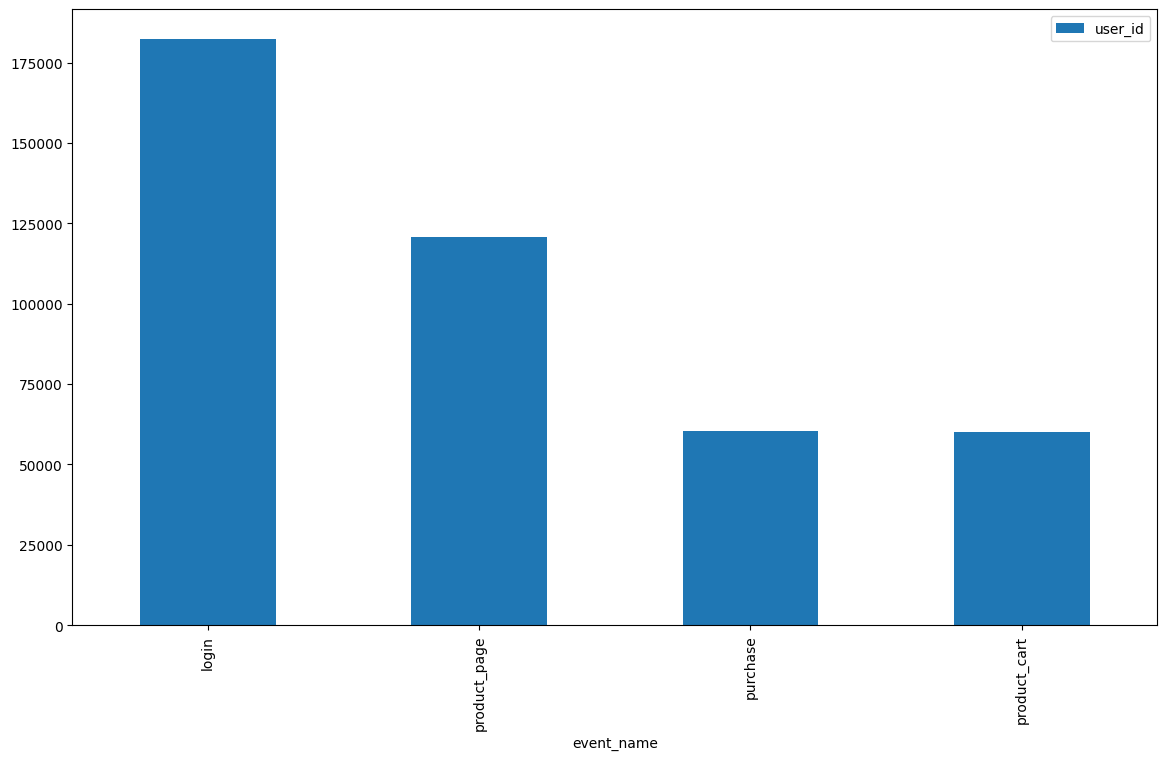

In [23]:
events_in_order = df_events.groupby('event_name')['user_id'].count().sort_values(ascending=False).reset_index()
display(events_in_order)
print()
events_in_order.plot(kind='bar', x='event_name', figsize=(14, 8))

In [24]:
avg_per_user = df_events.groupby('user_id').size().mean()
print(f'El promedio de eventos por usuario es: {avg_per_user:.0f}')

El promedio de eventos por usuario es: 7


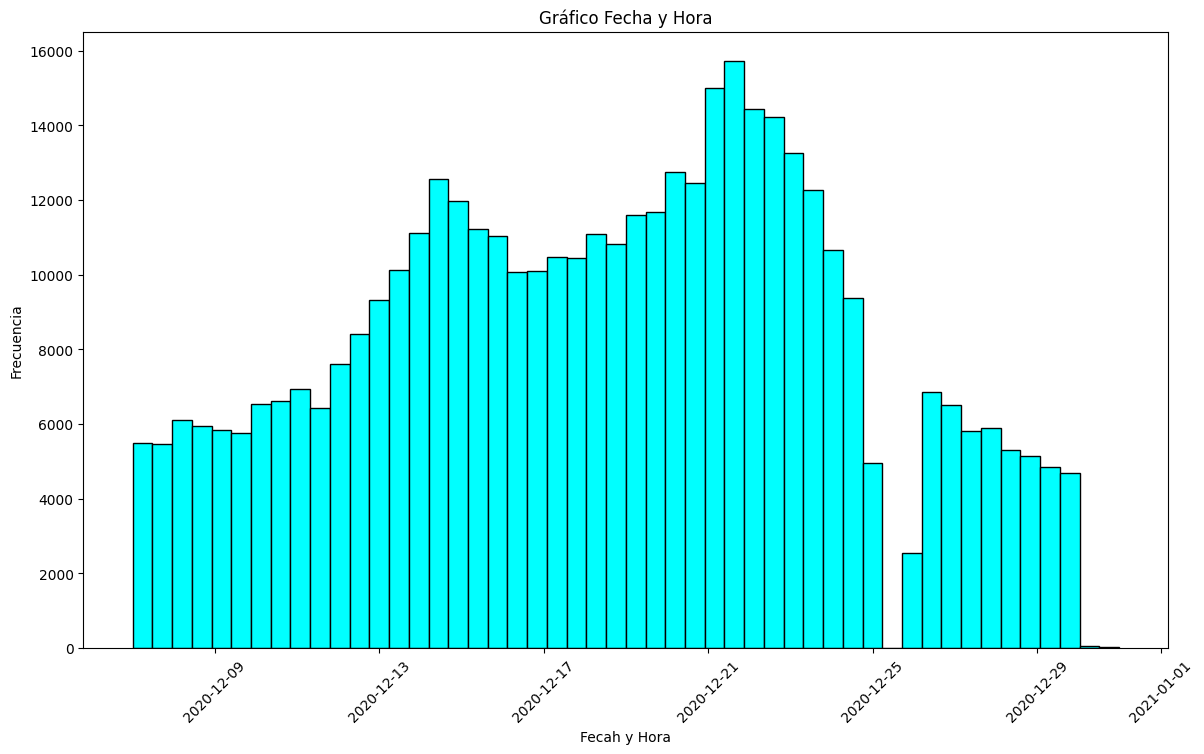

In [25]:
df_events['event_dt'] = pd.to_datetime(df_events['event_dt'])
plt.figure(figsize=(14, 8))
plt.hist(df_events['event_dt'], bins=50, color='cyan', edgecolor='black')
plt.title('Gráfico Fecha y Hora')
plt.xlabel('Fecah y Hora')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

In [26]:
funnel = ['login','product_page','product_cart','purchase']
users_event = df_events.groupby('event_name')['user_id'].nunique().loc[funnel]
display(users_event)


event_name
login           58696
product_page    38929
product_cart    19284
purchase        19568
Name: user_id, dtype: int64

In [27]:
retention = users_event / users_event.shift(1)
retention.iloc[0] = 1.0
cumulative_conv = users_event / users_event.iloc[0]

df_funnel = pd.DataFrame({'users':users_event,
                          'retention':retention,
                          'conv_cumulative %':cumulative_conv})
display(df_funnel)

,users,retention,conv_cumulative %
event_name,,,
login,58696,1.000000,1.000000
product_page,38929,0.663231,0.663231
product_cart,19284,0.495363,0.328540
purchase,19568,1.014727,0.333379


In [28]:
total_users = len(df_events['user_id'])
unique_users = df_events.groupby('event_name').agg({'user_id' : 'nunique'})
unique_users.sort_values(by='user_id', ascending = False, inplace = True)
conversion =  (unique_users / total_users) * 100 

display(conversion.round(2))

,user_id
event_name,
login,13.85
product_page,9.19
purchase,4.62
product_cart,4.55


El orden del embudo login-product_page-product_page-purchase donde hay una retención del mas del 30% entre cada etapa pero solo el 4.62 de los usuarios del total del datasert llegó a la última etapa del embudo

In [29]:
events_pivot = df_events.pivot_table(
    index='user_id',
    columns='event_name',
    values='event_dt', 
    aggfunc='min'
)

#events_pivot

step_1 = ~events_pivot['login'].isna()
step_2 = step_1 & (events_pivot['product_page'] > events_pivot['login'])
step_3 = step_2 & (events_pivot['product_cart'] > events_pivot['product_page'])
step_4 = step_3 & (events_pivot['purchase'] > events_pivot['product_cart'])

n_login = events_pivot[step_1].shape[0]
n_product_page = events_pivot[step_2].shape[0]
n_product_cart = events_pivot[step_3].shape[0]
n_purchase = events_pivot[step_4].shape[0]

print('Usuarios que hicieron login:', n_login)
print()
print('Usuarios que entraron a la página del producto:', n_product_page)
print()
print('Usuarios que agreagaron prodcutos al carriot:', n_product_cart)
print()
print('Usuarios que realizarono la compra:', n_purchase)

Usuarios que hicieron login: 58696

Usuarios que entraron a la página del producto: 22119

Usuarios que agreagaron prodcutos al carriot: 1347

Usuarios que realizarono la compra: 6


## 4.2Eventos por usuario y distribución equitativa entre las pruebas

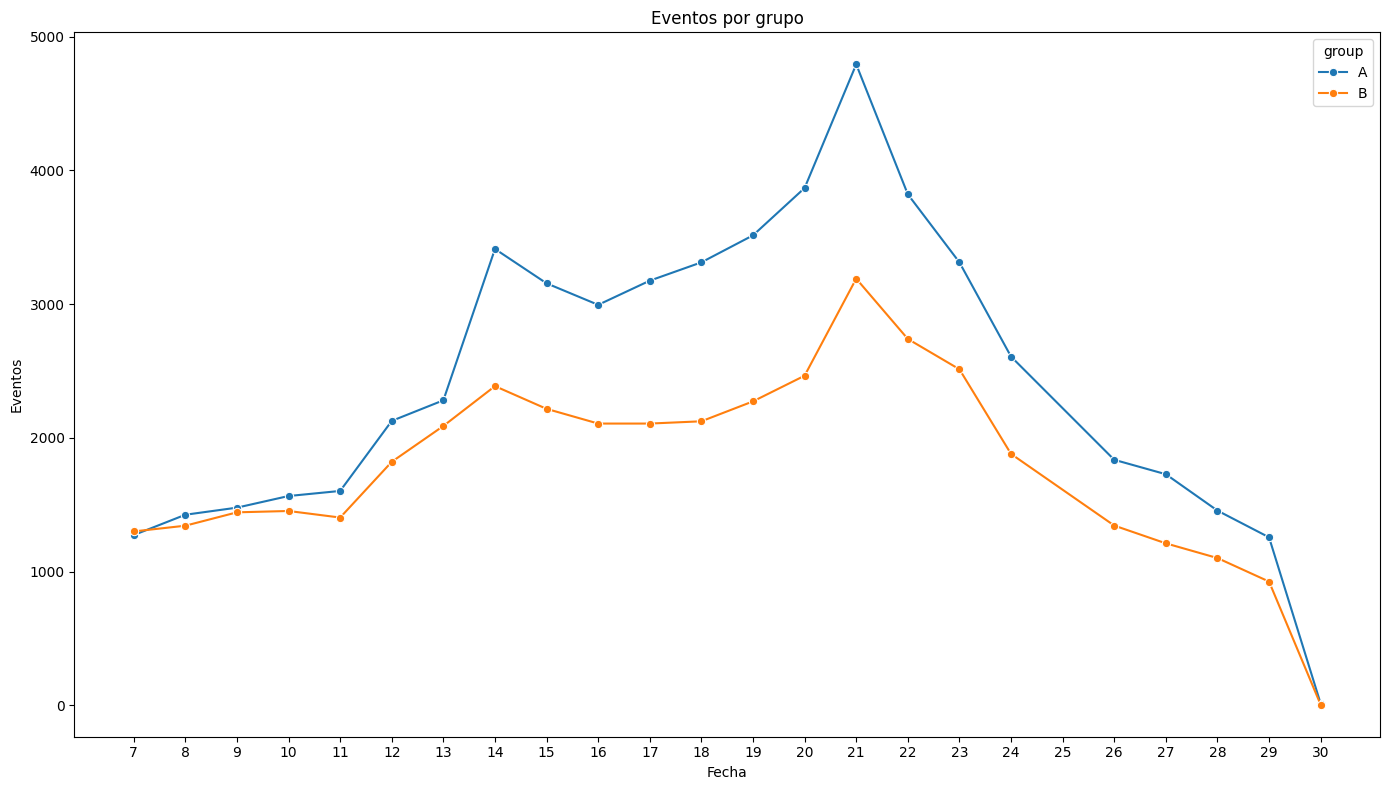

In [30]:
df_merge_events_participants = df_events.merge(df_participants_clean, on='user_id')
df_merge_events_participants['event_dt'] = pd.to_datetime(df_merge_events_participants['event_dt'])
df_merge_events_participants['event_day'] = df_merge_events_participants['event_dt'].dt.day


#df_merge_events_participants

df_grouped_1 = df_merge_events_participants.groupby(['group', 'event_day'], as_index=False)['event_name'].count()

#display(df_grouped_1)
plt.figure(figsize=(14, 8))
sns.lineplot(data=df_grouped_1, x='event_day', y='event_name', 
             hue='group', marker='o')
plt.title('Eventos por grupo')
plt.xlabel('Fecha')
plt.ylabel('Eventos')
plt.xticks(range(7, 31))
plt.tight_layout()
plt.show()

Si agrupamos los datasets de participantes de l aprueba  y los eventos y agrupamos por grupo, día de evento y contamos los eventos obtenemso un gráfico donde se observa la actividad de eventos por grupo por dia y construimos un gráfico con losa días y los eventos por grupo donde vemos que tanto para el grupo A como B desde el día 20 hasta el 24 es donde mayor actividad se registra y con el grupo A por encima del B, lo cual es normal ya que se travieza una fecha que sin duda nos dara un salto en los valores que es la navidad además si recordamos en el dataset de marketing hay evento de promoción christmas and new year promo.

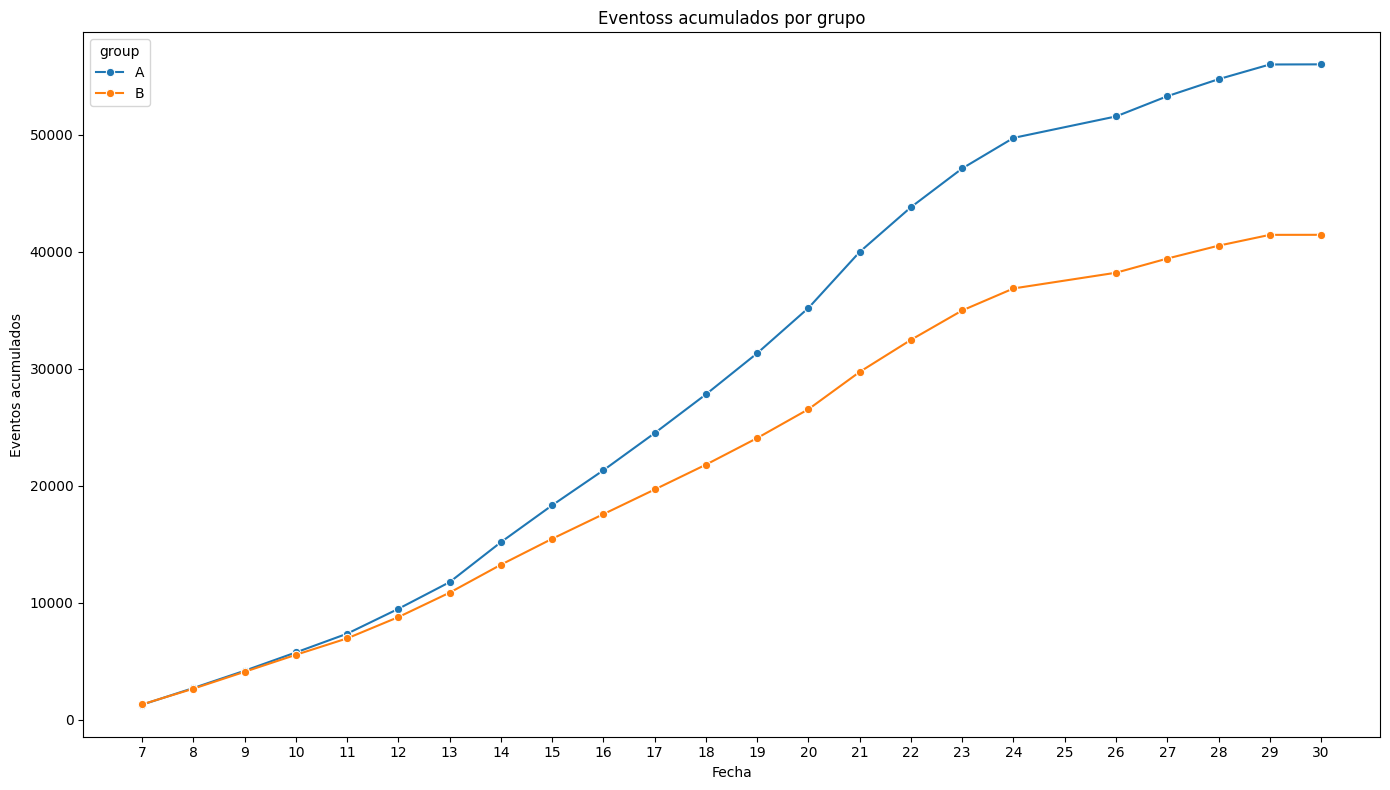

In [31]:
df_grouped_1['cumulative_events'] = df_grouped_1.groupby('group')['event_name'].cumsum()
#display(df_grouped_1)

plt.figure(figsize=(14, 8))
sns.lineplot(data=df_grouped_1, x='event_day', y='cumulative_events', 
             hue='group', marker='o')
plt.title('Eventoss acumulados por grupo')
plt.xlabel('Fecha')
plt.ylabel('Eventos acumulados')
plt.xticks(range(7, 31))
plt.tight_layout()
plt.show()

Construyendo un gráfico para los eventos acumulados tambíen encontrmos que el grupo A tiene mayor actividad pero de nuevo la actividad es completamente similar

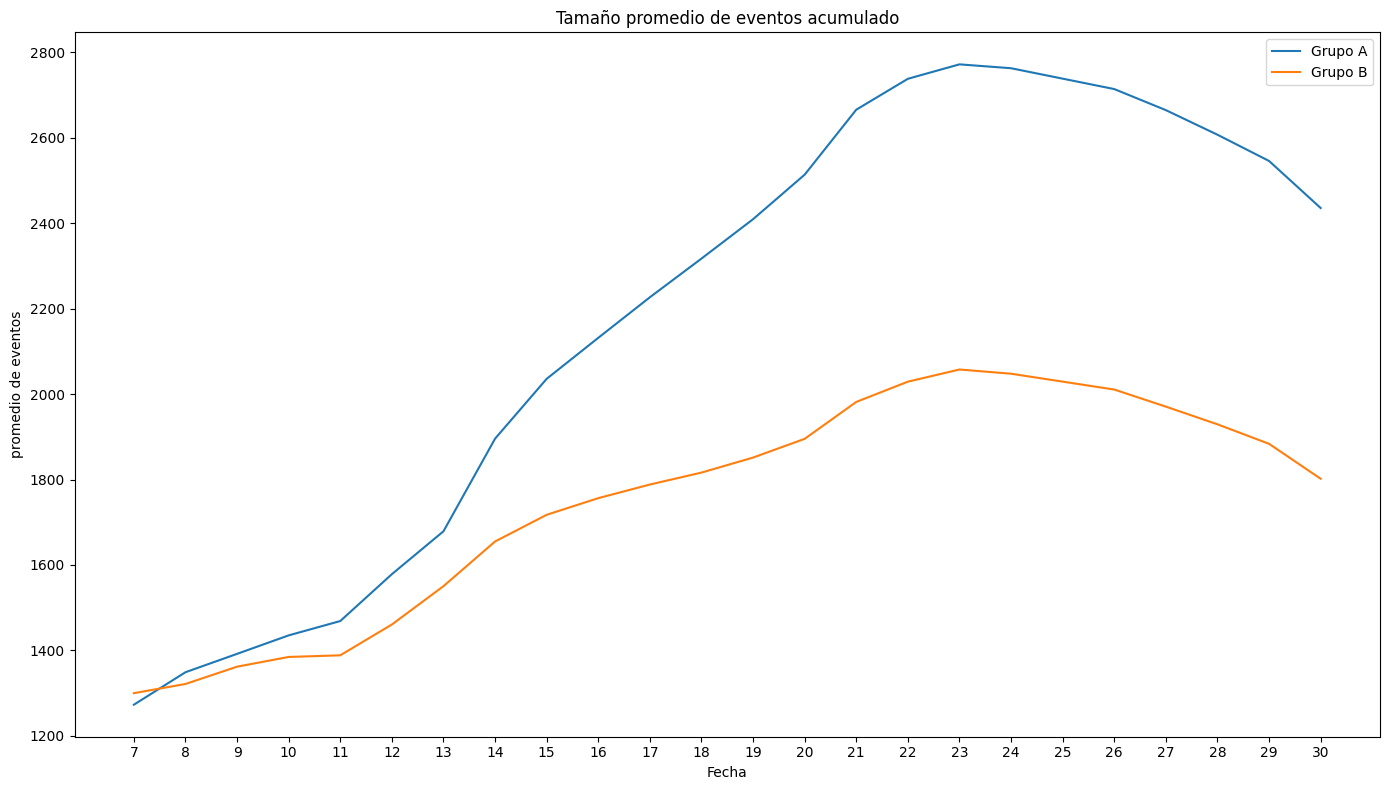

In [32]:
df_grouped_2 =df_grouped_1.groupby(['group', 'event_day'])['event_name'].mean()
#display(df_grouped_2)
print()
avg_events = (df_grouped_2.groupby(level=0, group_keys=False).apply(lambda s: s.expanding().mean()).reset_index(name='event_name'))
#display(avg_events)
print()
plt.figure(figsize=(14,8))
for g in ['A', 'B']:
    mask = avg_events['group'] == g
    plt.plot(avg_events.loc[mask, 'event_day'], avg_events.loc[mask, 'event_name'], label=f'Grupo {g}')
plt.title('Tamaño promedio de eventos acumulado')
plt.xlabel('Fecha'); plt.ylabel('promedio de eventos')
plt.xticks(range(7, 31))
plt.legend() ; plt.tight_layout(); plt.show()


group,event_day,A,B
0,7,1273.00,1300.00
1,8,1349.00,1321.50
2,9,1392.00,1362.00
3,10,1435.25,1384.75
4,11,1468.80,1388.60


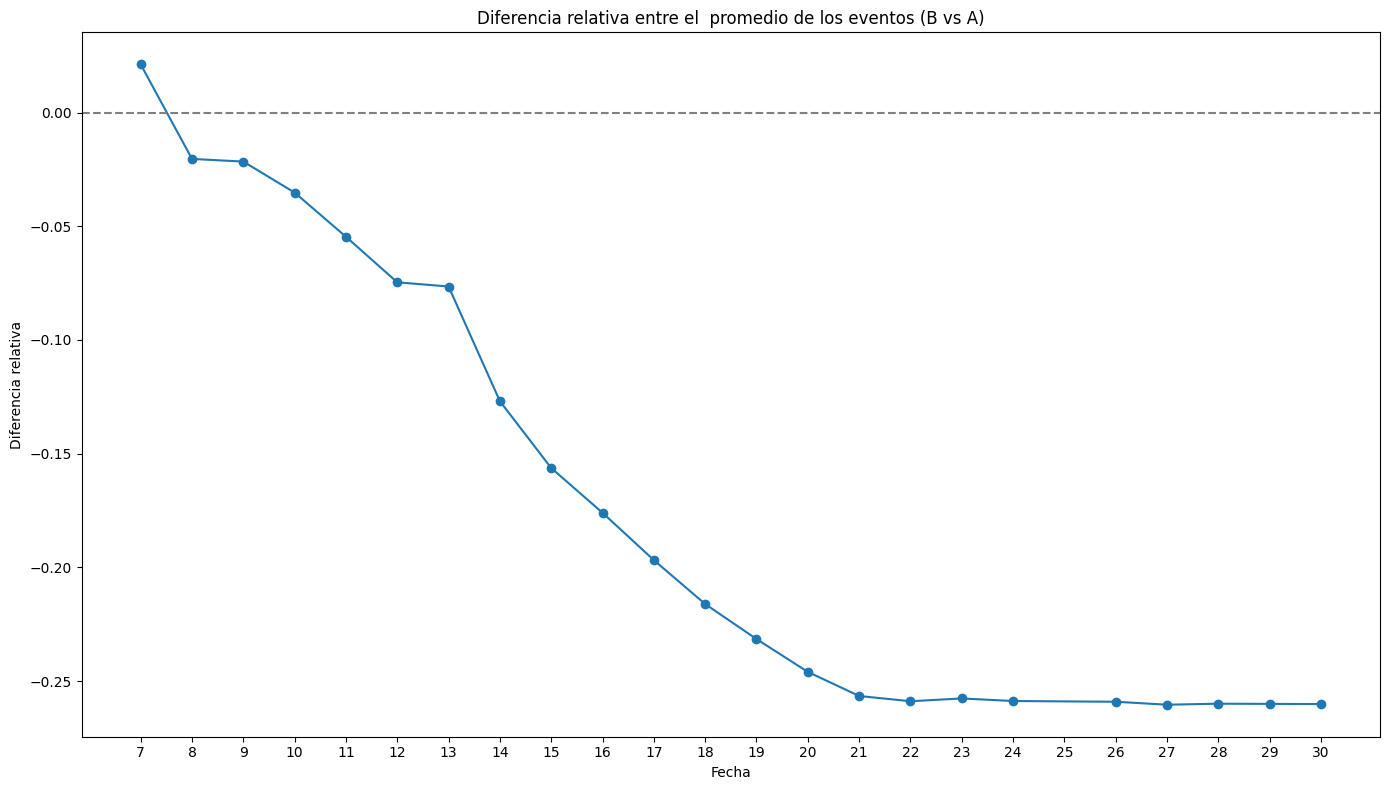

In [33]:
df_pivot_avg = (avg_events.pivot(index='event_day', columns='group', values='event_name').reset_index())
display(df_pivot_avg.head())

df_pivot_avg['relative_diff'] = (df_pivot_avg['B'] -df_pivot_avg['A']) / df_pivot_avg['A']

plt.figure(figsize=(14,8))
plt.plot(df_pivot_avg['event_day'], df_pivot_avg['relative_diff'], marker='o')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Diferencia relativa entre el  promedio de los eventos (B vs A)')
plt.xlabel('Fecha')
plt.ylabel('Diferencia relativa')
plt.xticks(range(7, 31))
plt.tight_layout()
plt.show()

La diferencia relativa entre el promedio de los eventos B vs A muestra una tendencia claramente negativa a lo largo del tiempo días. Esto indica que el grupo B ha tenido un rendimiento constantemente inferior a la del grupo A

C:\Users\PC\AppData\Local\Temp\ipykernel_62336\533082946.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_size, x='group', y='count_users', palette='BuGn')


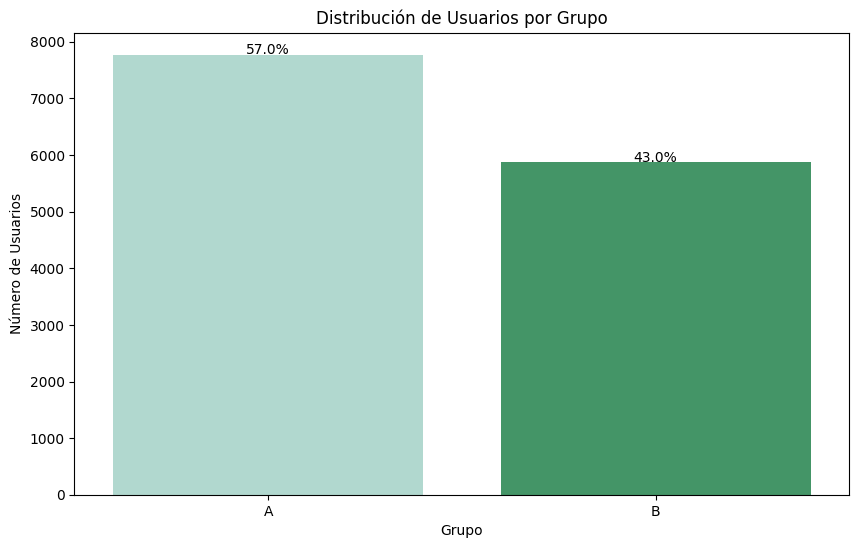

In [34]:
group_size = df_participants_clean.groupby('group')['user_id'].count().reset_index(name='count_users')
grand_total = group_size['count_users'].sum()
group_size['proportion'] = group_size['count_users'] / grand_total


plt.figure(figsize=(10,6))
sns.barplot(data=group_size, x='group', y='count_users', palette='BuGn')

plt.title('Distribución de Usuarios por Grupo')
plt.xlabel('Grupo')
plt.ylabel('Número de Usuarios')

# mostrar el porcentaje que cada muestra representa
for i, row in group_size.iterrows():
    plt.text(i, row['count_users'] + 10, f"{row['proportion']:.1%}", ha='center', fontsize=10)


Aquí observamos que si hay u7na diferencia entre ambas muestras de más del 13% lo cual puede traernos problemas con la prueba A/B y sesgar los resultados. Por lo que no podemos decir que estan distribuidos de maneras equitativas.

## 4.3¿Hay usuarios que están presentes en ambas muestras?  

## 4.4¿Cómo se distribuye el número de eventos entre los días?


¿Hay usuarios que están presentes en ambas muestras?  

Si, si los hay pero ya quedó resuelto en los pasoso anteriores.  

¿Cómo se distribuye el número de eventos entre los días?  

En los gráficos de arriba también ha quedado los eventos por día.


## 4.5¿Hay alguna peculiaridad en los datos que hay que tener en cuenta antes de iniciar la prueba A/B?

In [35]:
events_total_users = df_events.groupby('user_id')['event_name'].count().reset_index(name='total_events')

events_total_users.sort_values(by='total_events', ascending=False)

,user_id,total_events
37526,A3917F81482141F2,36
7403,203773F2A53233A8,32
3965,11285A53EC2B2042,32
42807,BA87FD8D70D63CC6,32
12472,365C8B51237C61AF,32
...,...,...
27886,7A2073BD661AF70D,1
15918,452225689815A700,1
45177,C5293D68FDC0D086,1
52381,E48564406C361C95,1


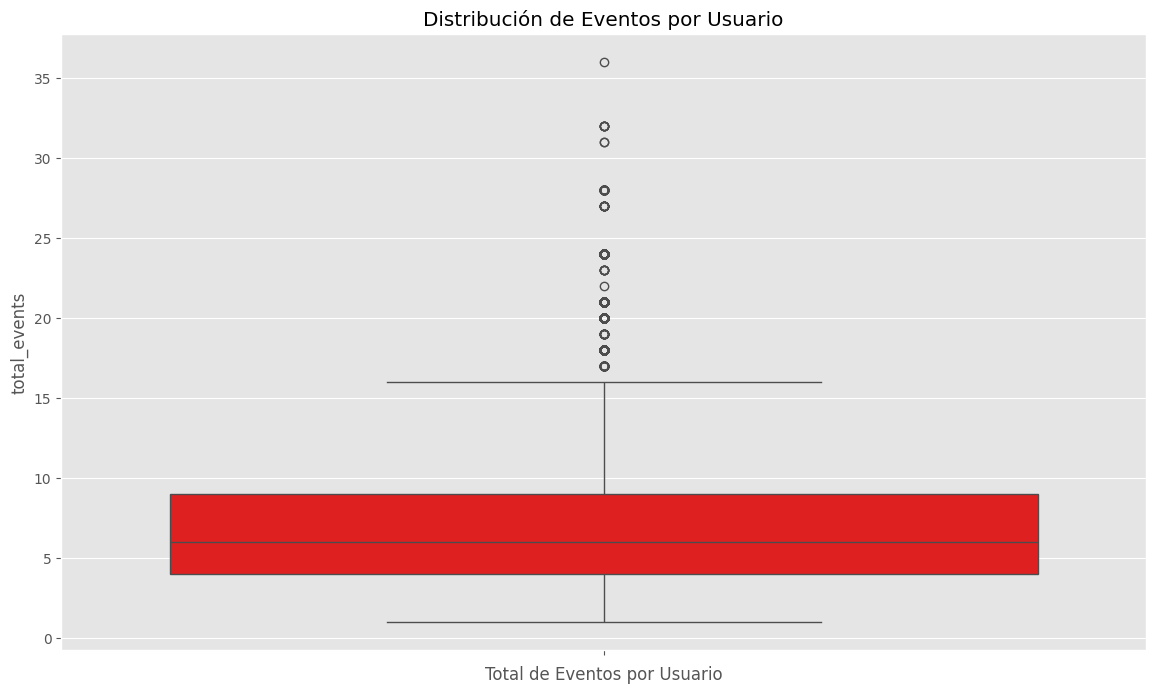

In [36]:
with plt.style.context('ggplot'):
    plt.figure(figsize=(14, 8))
    sns.boxplot(data=events_total_users, y='total_events', color='red')

    plt.title('Distribución de Eventos por Usuario')
    plt.xlabel('Total de Eventos por Usuario')
    
    plt.show()

In [37]:
print('La media es:', events_total_users['total_events'].mean())
print()
print('La mediana es:', events_total_users['total_events'].median())
print()
print('La moda es:', events_total_users['total_events'].mode())

La media es: 7.218728174028585

La mediana es: 6.0

La moda es: 0    6
Name: total_events, dtype: int64


In [38]:
print('estos son los percentiles', np.percentile(events_total_users['total_events'], [90,95,99,100]))

estos son los percentiles [12. 15. 20. 36.]


¿Qué otras peculiaridades encontramos en los datos?, bueno primero es que la hacer el  análisis del embudo sin duda hay algo para llamar la atención y es que purchase tiene mas cantidad de usuarios que producto_page también podemos decir que hay valores atípicos con 1% realiza 20 eventos y 36 es número máximo de eventos por usuario. Lo cual se aleja bastante de la media de 7 eventods por usuario.

## 5Evaluar los resultados de la prueba A/B:

## 5.1¿Qué puedes decir sobre los resultados de la prueba A/B?

In [39]:
df_test = df_merge_events_participants.merge(df_users_in_21d, on='user_id', how='inner')
df_test['date'] = df_test['event_dt'].dt.date

df_test['date'] = pd.to_datetime(df_test['date'])
df_test['days_signup'] = (df_test['date'] - df_test['first_date']).dt.days

display(df_test)

,user_id,event_dt,event_name,details,group,ab_test,event_day,first_date,region,device,date,days_signup
0,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99,B,interface_eu_test,7,2020-12-07,EU,iPhone,2020-12-07,0
1,831887FE7F2D6CBA,2020-12-07 06:50:29,purchase,4.99,A,recommender_system_test,7,2020-12-07,EU,Android,2020-12-07,0
2,A92195E3CFB83DBD,2020-12-07 00:32:07,purchase,4.99,A,interface_eu_test,7,2020-12-07,EU,Android,2020-12-07,0
3,354D653172FF2A2D,2020-12-07 15:45:11,purchase,4.99,A,interface_eu_test,7,2020-12-07,EU,Mac,2020-12-07,0
4,7FCD34F47C13A9AC,2020-12-07 22:06:13,purchase,9.99,B,interface_eu_test,7,2020-12-07,EU,PC,2020-12-07,0
...,...,...,...,...,...,...,...,...,...,...,...,...
91945,75845C83258FBF73,2020-12-30 06:42:52,login,NaN,B,recommender_system_test,30,2020-12-07,EU,Android,2020-12-30,23
91946,4584E51B99DE51AE,2020-12-30 07:39:32,login,NaN,A,interface_eu_test,30,2020-12-07,EU,Mac,2020-12-30,23
91947,9DF4F595A906A0BA,2020-12-30 18:28:55,login,NaN,B,interface_eu_test,30,2020-12-07,EU,Android,2020-12-30,23
91948,6181F3835EBE66BF,2020-12-30 12:00:00,login,NaN,A,interface_eu_test,30,2020-12-07,EU,Android,2020-12-30,23


In [40]:
filter_days = df_test[df_test['days_signup'] <= 14]
display(filter_days)
group_a = filter_days[filter_days['group'] == 'A']
group_b = filter_days[filter_days['group'] == 'B']

print('Usuarios grupo a = ', group_a['user_id'].count())
print('Usuarios únicos grupo a = ', group_a['user_id'].nunique())
print()
print('Usuarios grupo b = ', group_b['user_id'].count())
print('Usuarios únicos grupo b = ', group_b['user_id'].nunique())


,user_id,event_dt,event_name,details,group,ab_test,event_day,first_date,region,device,date,days_signup
0,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99,B,interface_eu_test,7,2020-12-07,EU,iPhone,2020-12-07,0
1,831887FE7F2D6CBA,2020-12-07 06:50:29,purchase,4.99,A,recommender_system_test,7,2020-12-07,EU,Android,2020-12-07,0
2,A92195E3CFB83DBD,2020-12-07 00:32:07,purchase,4.99,A,interface_eu_test,7,2020-12-07,EU,Android,2020-12-07,0
3,354D653172FF2A2D,2020-12-07 15:45:11,purchase,4.99,A,interface_eu_test,7,2020-12-07,EU,Mac,2020-12-07,0
4,7FCD34F47C13A9AC,2020-12-07 22:06:13,purchase,9.99,B,interface_eu_test,7,2020-12-07,EU,PC,2020-12-07,0
...,...,...,...,...,...,...,...,...,...,...,...,...
91939,BCEC881B3C573B2B,2020-12-29 08:17:16,login,NaN,A,interface_eu_test,29,2020-12-20,EU,PC,2020-12-29,9
91940,E63A1230B1D1DC3C,2020-12-29 23:20:00,login,NaN,A,interface_eu_test,29,2020-12-20,EU,PC,2020-12-29,9
91941,553BAE96C6EB6240,2020-12-29 14:09:14,login,NaN,A,recommender_system_test,29,2020-12-20,EU,Android,2020-12-29,9
91942,8CE3B6FD918462B4,2020-12-29 17:55:44,login,NaN,B,interface_eu_test,29,2020-12-20,EU,PC,2020-12-29,9


Usuarios grupo a =  51774
Usuarios únicos grupo a =  6943

Usuarios grupo b =  37256
Usuarios únicos grupo b =  5250


 Ya habiamos encontrado que las diferencias entre el grupo A y B es de un 13% aquí lo confirmamios 

In [41]:
total_a = group_a['user_id'].shape[0]
unique_a = group_a.groupby('event_name').agg({'user_id': 'nunique'}).sort_values(by='user_id', ascending = False)

total_b = group_b['user_id'].shape[0]
unique_b = group_b.groupby('event_name').agg({'user_id': 'nunique'}).sort_values(by='user_id', ascending = False)

conversion_a = (unique_a / total_a) * 100
conversion_a = conversion_a.sort_values(by='user_id', ascending=False).reset_index()
conversion_a.columns = ['Event', 'Percentage']

conversion_b = (unique_b / total_b) * 100
conversion_b = conversion_b.sort_values(by='user_id', ascending=False).reset_index()
conversion_b.columns = ['Event', 'Percentage']
print('Tabla de conversión para el grupo A:\n', conversion_a.round(2))
print()
print('Tabla de conversión para el grupo B:\n', conversion_b.round(2))

Tabla de conversión para el grupo A:
           Event  Percentage
0         login       13.41
1  product_page        8.89
2      purchase        4.61
3  product_cart        4.26

Tabla de conversión para el grupo B:
           Event  Percentage
0         login       14.09
1  product_page        9.06
2  product_cart        4.67
3      purchase        4.58


Si realizamos una comparación entre el grupo A y el Grupo B a través del embudo observamos que hay un aumento entre login y prodcut_page pero la diferencia entre product_cart y purchase es apenas del 0.28 por ciento con lo cual no podemos decir quela prueba A/B sea del todo exitosa a pesar de lso aumentos encontrados.

## 5.2Utiliza una prueba z para comprobar la diferencia estadística entre las proporciones.

In [42]:
q95_events = np.percentile(events_total_users['total_events'], 95)
print('El percentil en un q= 95 es igual a: ', q95_events)             

El percentil en un q= 95 es igual a:  15.0


Aproximandonos a realizar una preuba z para comprobar alguna diferencia estadístiva sacamos le precentil de los evento totales con un q=95 ya que el resto de ouliers estan muy alejados de la media y la mediana como se observó anteriormente en gráfico de caja.

In [43]:
print('Usuarios únicos', filter_days['user_id'].nunique())
df_test_z = filter_days.groupby('group').agg({'user_id':'nunique', 'event_name':'count'})
display(df_test_z)
success = df_test_z['user_id']
trials = df_test_z['event_name']

Usuarios únicos 12193


,user_id,event_name
group,,
A,6943,51774
B,5250,37256


Si realizamops una prueba z estadística entre el grupo A y el grupoa B contemaplamdo los outliers encontrados para los eventos observamos que si hay uandiferencia significativa estadísticamente  ya que el resultado de p value es menor a 0.05

In [44]:
a_events = group_a.groupby('user_id')['event_name'].count().reset_index()
b_events = group_b.groupby('user_id')['event_name'].count().reset_index()

u_stat, pval = st.mannwhitneyu(a_events['event_name'], b_events['event_name'], alternative='two-sided')
print(f'U estadístico: {u_stat}, p-valor: {pval:.5f}')

U estadístico: 19011262.5, p-valor: 0.00004


In [45]:
q95_test = filter_days.groupby(['group', 'user_id'])['event_name'].count().reset_index()
q95_test = q95_test[q95_test['event_name'] <= 15]

a_events = a_events[a_events['event_name'] <= 15]
b_events = b_events[b_events['event_name'] <= 15]
print(len(a_events))
print()
print(len(b_events))


6574

5039


Habiamos calculado previamente un percentil de q95 el cual es igual a 15 si filtramos aquellos usuarios con menos  de 15 eventos para d enuevo realizar las pruebas

In [46]:
u_stat1, pval1 = st.mannwhitneyu(a_events['event_name'], b_events['event_name'], alternative='two-sided')
print(f'U estadístico: {u_stat1}, p-valor: {pval1:.5f}')

U estadístico: 17111668.5, p-valor: 0.00195


## 6 Describe tus conclusiones con respecto a la etapa EDA y los resultados de la prueba A/B.

Una tienda on line realizo una prueba A/B con la finalidad de encontrar los siguientes resultados: dentro de los 14 días posteriores a la inscripción, los usuarios mostrarán una mejor conversión en vistas de la página del producto (el evento product_page), instancias de agregar artículos al carrito de compras (product_card) y compras (purchase). En cada etapa del embudo product_page → product_card → purchase, habrá al menos un 10% de aumento.   
Se proporcionaron 4 datasets para realizar dicho análisis:  
ab_project_marketing_events_us.csv — el calendario de eventos de marketing para 2020  
final_ab_new_users_upd_us.csv — todos los usuarios que se registraron en la tienda en línea desde el 7 hasta el 21 de diciembre de 2020  
final_ab_events_upd_us.csv — todos los eventos de los nuevos usuarios en el período comprendido entre el 7 de diciembre de 2020 y el 1 de enero de 2021  
final_ab_participants_upd_us.csv — tabla con los datos de los participantes de la prueba  
Pero abandonaron la culminación de dicha prueba dejando algunos aspectos técnicos y los datasets mencionados; para revisar la información y los resultados de las pruebas lo primero es la importación de librerías y datasets, después se procedió a una revisión y procesamiento de datos donde se limpiaron los datasets de aquellos valores duplicados, valores vacíos o nulos, así como el cambio de ciertos valores de columnas de un tipo a otros específicamente  de tipo object  datetime, pero solo eliminando aquellos que no impactaran en las pruebas como por ejemplo todos los valores NaN en al columna details del dataset events donde no se eliminaron ya que esos valores si debían ser NaN . También se encontraron eventos simultáneos, pero aún asís parecía no ser un error ya que la buscar usuarios, fecha y evento los duplicados desaparecían.  
En otra instancia de la revisión se hizo un análisis exploratorio de datos (EDA) donde se estudió el embudo en sus diferentes etapas donde se encontró que debía definirse así:  
Login-prodcut_page-prodcut_cart-purchase  

Donde encontramos que de los más de 18,000 que hicieron log in una tercera parte o sea más de 6,000terminaron el embudo, promediando 7 eventos por usuario y donde solo el 4.62 de los usuarios del total del dataset llegó a la última etapa del embudo.  

Y al final tan solo 6 usuarios realizaron una compra, un n{umero muy bajo con respecto al total de visitas en la página.  

Al final también encontramos que las muestras A y B no están del todod bien distribuidas hay uan diferencia de 13% entre ellas.  

Para todos los usuarios de la prueba: recommender_system_test se descubrió que había mas de 400 usuarios que aparecían en ambas pruebas al eliminarlos perdimos un 6% de la muestra, pero ahora teníamos muestras limpias.  

Dentro de la distribución de eventos por días encontramos que tanto para el grupo A como B el comportamiento es prácticamente el mismo, pero teniendo mayo cantidad de actividad el grupo A y cabe destacar que hay un gran pico hacia el día 21 de diciembre esto obviamente producido por la cercanía de la navidad (es un punto a considerar para una siguiente prueba ya que un evento asi puede comprometer nuestra fiabilidad en las pruebas.  

¿Qué otras peculiaridades encontramos en los datos?, bueno primero es que la hacer el análisis del embudo sin duda hay algo para llamar la atención y es que purchase tiene más cantidad de usuarios que producto_page también podemos decir que hay valores atípicos con 1% realiza 20 eventos y 36 es número máximo de eventos por usuario. Lo cual se aleja bastante de la media de 7 eventos por usuario.  

Y ya por último se realizaron una comparación entre las tasas de conversión de un grupo y otro y observamos que hay un aumento entre login y prodcut_page pero la diferencia entre product_cart y purchase es apenas del 0.28 por ciento con lo cual no podemos decir que la prueba A/B sea del todo exitosa a pesar de los aumentos encontrados y como un último paso  los  z test proprtion dentro de los eventos arrojan que no hay diferencia significativa si eliminamos los outliers de las muestras.
